In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
housing = pd.read_csv('../datasets/housing.csv')

In [45]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


# Exploratory Data Analysis

- Print 
    - shape
    - columns
    - data types
- Univariate analysis
    - Descriptive Statistics
    - boxplot
    - histogram
- Bivariate
    - scatter plot
    - Pairplot
    - Correlation plot

# Option 01:
Manual EDA

# Option 02:
`ydata_profiling`

# Option 03:
`dtale`

In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
profile = ProfileReport(housing, title='Housing Data Profiling Report')
profile.to_file("../data_reports/housing_data_profiling.html")

In [ ]:
import dtale

In [ ]:
d = dtale.show(housing)
d.open_browser()

In [ ]:
d.kill()

# Create train test

In [46]:
from sklearn.model_selection import train_test_split

# Random split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

print(f"Rows in train set: {len(train_set)}\nRows in test set: {len(test_set)}")

Rows in train set: 16512
Rows in test set: 4128


In [47]:
housing['median_income'].describe()

count    20640.000000
mean         3.870671
std          1.899822
min          0.499900
25%          2.563400
50%          3.534800
75%          4.743250
max         15.000100
Name: median_income, dtype: float64

In [48]:
housing['income_cat'] = pd.cut(housing['median_income'], 
       bins=[0., 1.5, 3.0, 4.5, 6., np.inf], 
       labels=[1, 2, 3, 4, 5])

housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,income_cat
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,5
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,5
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,5
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,4
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,3


In [49]:
len(housing)

20640

In [50]:
housing['income_cat'].value_counts() / len(housing) * 100

income_cat
3    35.058140
2    31.884690
4    17.630814
5    11.443798
1     3.982558
Name: count, dtype: float64

In [51]:
strat_train_set, strat_test_set = train_test_split(housing, 
                                                   test_size=0.2, 
                                                   random_state=42, 
                                                   stratify=housing['income_cat'])

In [52]:
def income_cat_proportions(data):
    return data['income_cat'].value_counts() / len(data)

train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, random_state=42, stratify=housing['income_cat'])

compare_props = pd.DataFrame({
    'Overall': income_cat_proportions(housing),
    'Stratified': income_cat_proportions(strat_test_set),
    'Random': income_cat_proportions(test_set),
}).sort_index()

compare_props['Rand. %error'] = 100 * compare_props['Random'] / compare_props['Overall'] - 100
compare_props['Strat. %error'] = 100 * compare_props['Stratified'] / compare_props['Overall'] - 100

compare_props

,Overall,Stratified,Random,Rand. %error,Strat. %error
income_cat,,,,,
1,0.039826,0.039971,0.040213,0.973236,0.364964
2,0.318847,0.318798,0.324370,1.732260,-0.015195
3,0.350581,0.350533,0.358527,2.266446,-0.013820
4,0.176308,0.176357,0.167393,-5.056334,0.027480
5,0.114438,0.114341,0.109496,-4.318374,-0.084674


In [53]:
# axis=0 means drop the row
# axis=1 means drop the column
housing = strat_train_set.drop(['median_house_value'], axis=1)
housing_labels = strat_train_set['median_house_value'].copy()

In [54]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,2
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,5
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,2
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,2
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,3


In [55]:
housing_labels.head()

12655     72100.0
15502    279600.0
2908      82700.0
14053    112500.0
20496    238300.0
Name: median_house_value, dtype: float64

# Data Preprocessing

## Missing Values

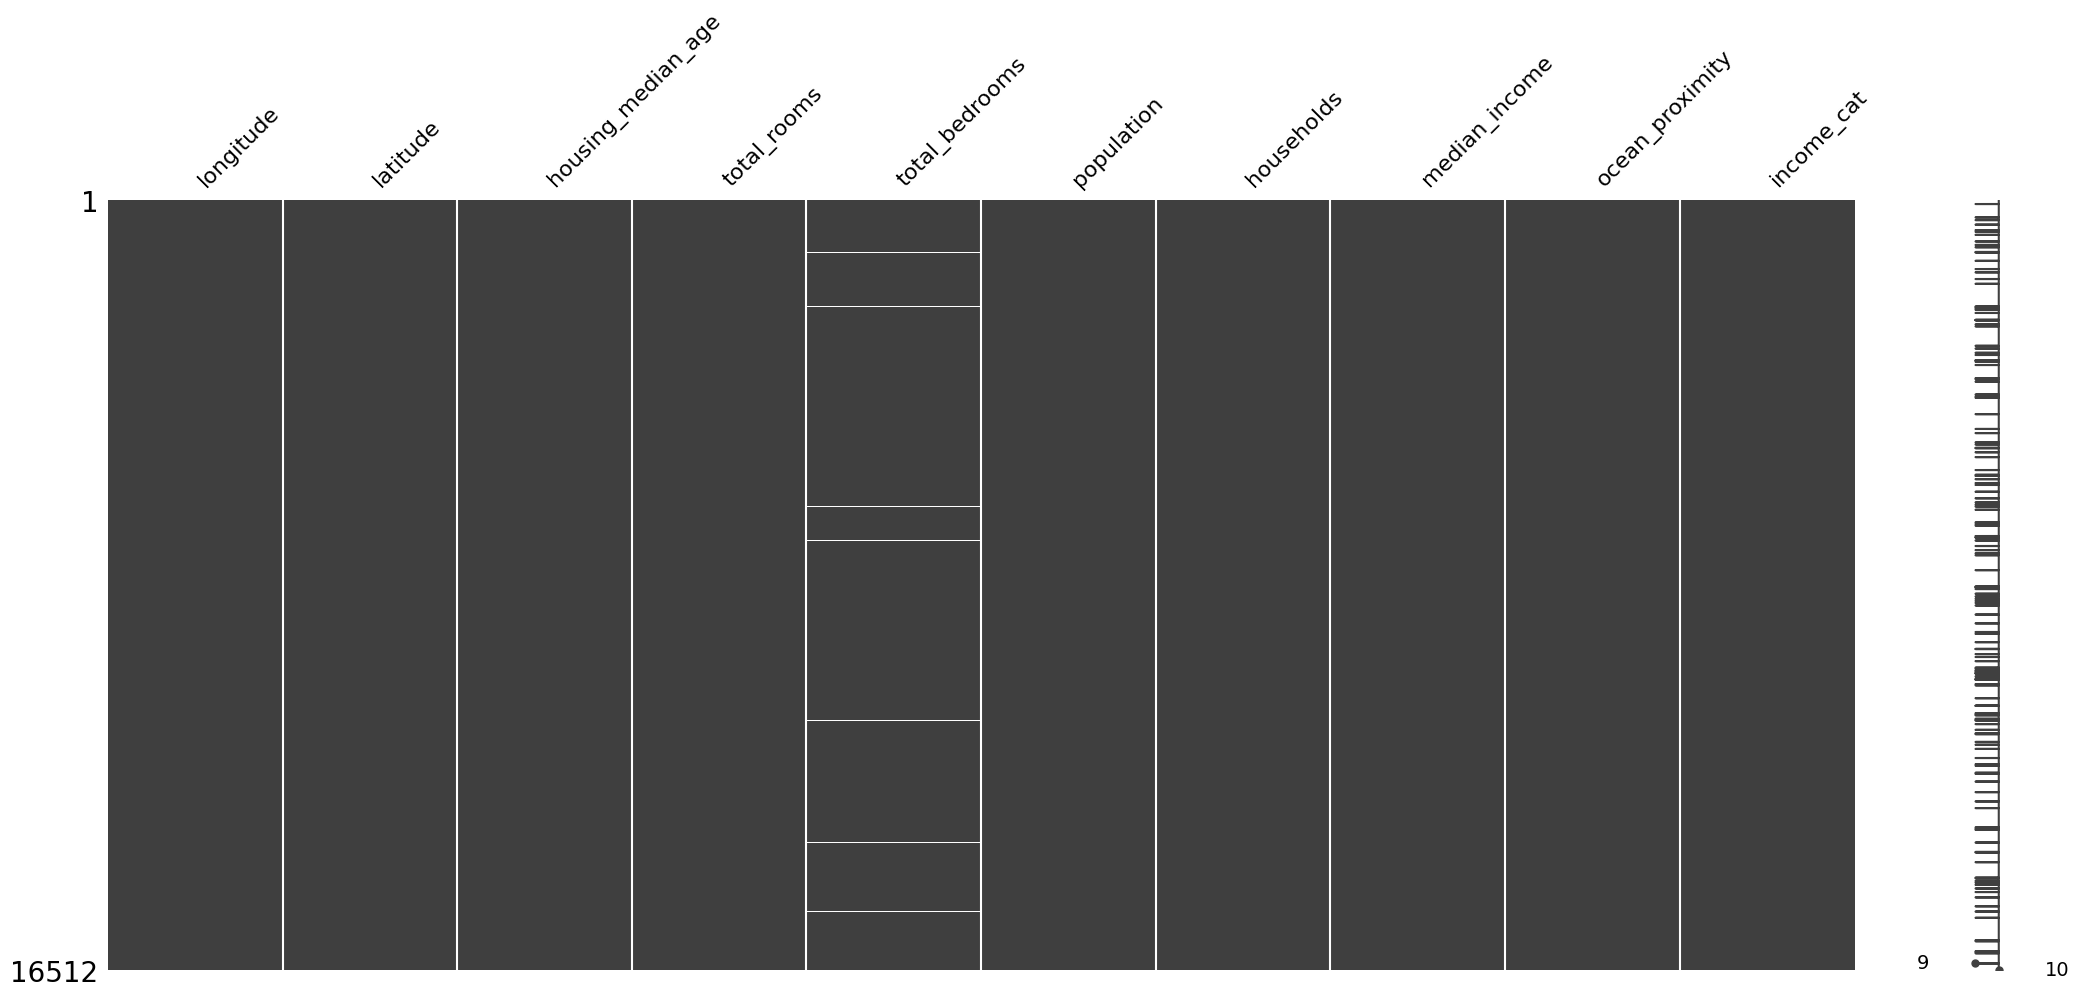

In [56]:
import missingno as msno

%matplotlib inline

msno.matrix(housing)
plt.show()

In [57]:
housing[housing.isnull().any(axis=1)]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
1606,-122.08,37.88,26.0,2947.0,NaN,825.0,626.0,2.9330,NEAR BAY,2
10915,-117.87,33.73,45.0,2264.0,NaN,1970.0,499.0,3.4193,<1H OCEAN,3
19150,-122.70,38.35,14.0,2313.0,NaN,954.0,397.0,3.7813,<1H OCEAN,3
4186,-118.23,34.13,48.0,1308.0,NaN,835.0,294.0,4.2891,<1H OCEAN,3
16885,-122.40,37.58,26.0,3281.0,NaN,1145.0,480.0,6.3580,NEAR OCEAN,5
...,...,...,...,...,...,...,...,...,...,...
1350,-121.95,38.03,5.0,5526.0,NaN,3207.0,1012.0,4.0767,INLAND,3
4691,-118.37,34.07,50.0,2519.0,NaN,1117.0,516.0,4.3667,<1H OCEAN,3
9149,-118.50,34.46,17.0,10267.0,NaN,4956.0,1483.0,5.5061,<1H OCEAN,4
16757,-122.48,37.70,33.0,4492.0,NaN,3477.0,1537.0,3.0546,NEAR OCEAN,3


In [59]:
housing_num = housing.select_dtypes(include=np.number)
housing_num.shape

(16512, 8)

In [60]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median') # strategy can also be mean or most_frequent
imputer.fit(housing_num)

SimpleImputer(strategy='median')

In [61]:
imputer.statistics_

array([-118.51   ,   34.26   ,   29.     , 2119.     ,  433.     ,
       1164.     ,  408.     ,    3.54155])

In [62]:
X = imputer.transform(housing_num)
X

array([[-1.2146e+02,  3.8520e+01,  2.9000e+01, ...,  2.2370e+03,
         7.0600e+02,  2.1736e+00],
       [-1.1723e+02,  3.3090e+01,  7.0000e+00, ...,  2.0150e+03,
         7.6800e+02,  6.3373e+00],
       [-1.1904e+02,  3.5370e+01,  4.4000e+01, ...,  6.6700e+02,
         3.0000e+02,  2.8750e+00],
       ...,
       [-1.2272e+02,  3.8440e+01,  4.8000e+01, ...,  4.5800e+02,
         1.7200e+02,  3.1797e+00],
       [-1.2270e+02,  3.8310e+01,  1.4000e+01, ...,  1.2080e+03,
         5.0100e+02,  4.1964e+00],
       [-1.2214e+02,  3.9970e+01,  2.7000e+01, ...,  6.2500e+02,
         1.9700e+02,  3.1319e+00]])

In [63]:
housing_tr = pd.DataFrame(X, 
                          columns=housing_num.columns, 
                          index=housing_num.index)
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964
...,...,...,...,...,...,...,...,...
15174,-117.07,33.03,14.0,6665.0,1231.0,2026.0,1001.0,5.0900
12661,-121.42,38.51,15.0,7901.0,1422.0,4769.0,1418.0,2.8139
19263,-122.72,38.44,48.0,707.0,166.0,458.0,172.0,3.1797
19140,-122.70,38.31,14.0,3155.0,580.0,1208.0,501.0,4.1964


In [65]:
housing_tr.loc[[12655, 15502]]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373


In [66]:
housing_tr.loc[housing[housing.isnull().any(axis=1)].index.values]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
1606,-122.08,37.88,26.0,2947.0,433.0,825.0,626.0,2.9330
10915,-117.87,33.73,45.0,2264.0,433.0,1970.0,499.0,3.4193
19150,-122.70,38.35,14.0,2313.0,433.0,954.0,397.0,3.7813
4186,-118.23,34.13,48.0,1308.0,433.0,835.0,294.0,4.2891
16885,-122.40,37.58,26.0,3281.0,433.0,1145.0,480.0,6.3580
...,...,...,...,...,...,...,...,...
1350,-121.95,38.03,5.0,5526.0,433.0,3207.0,1012.0,4.0767
4691,-118.37,34.07,50.0,2519.0,433.0,1117.0,516.0,4.3667
9149,-118.50,34.46,17.0,10267.0,433.0,4956.0,1483.0,5.5061
16757,-122.48,37.70,33.0,4492.0,433.0,3477.0,1537.0,3.0546


<Axes: >

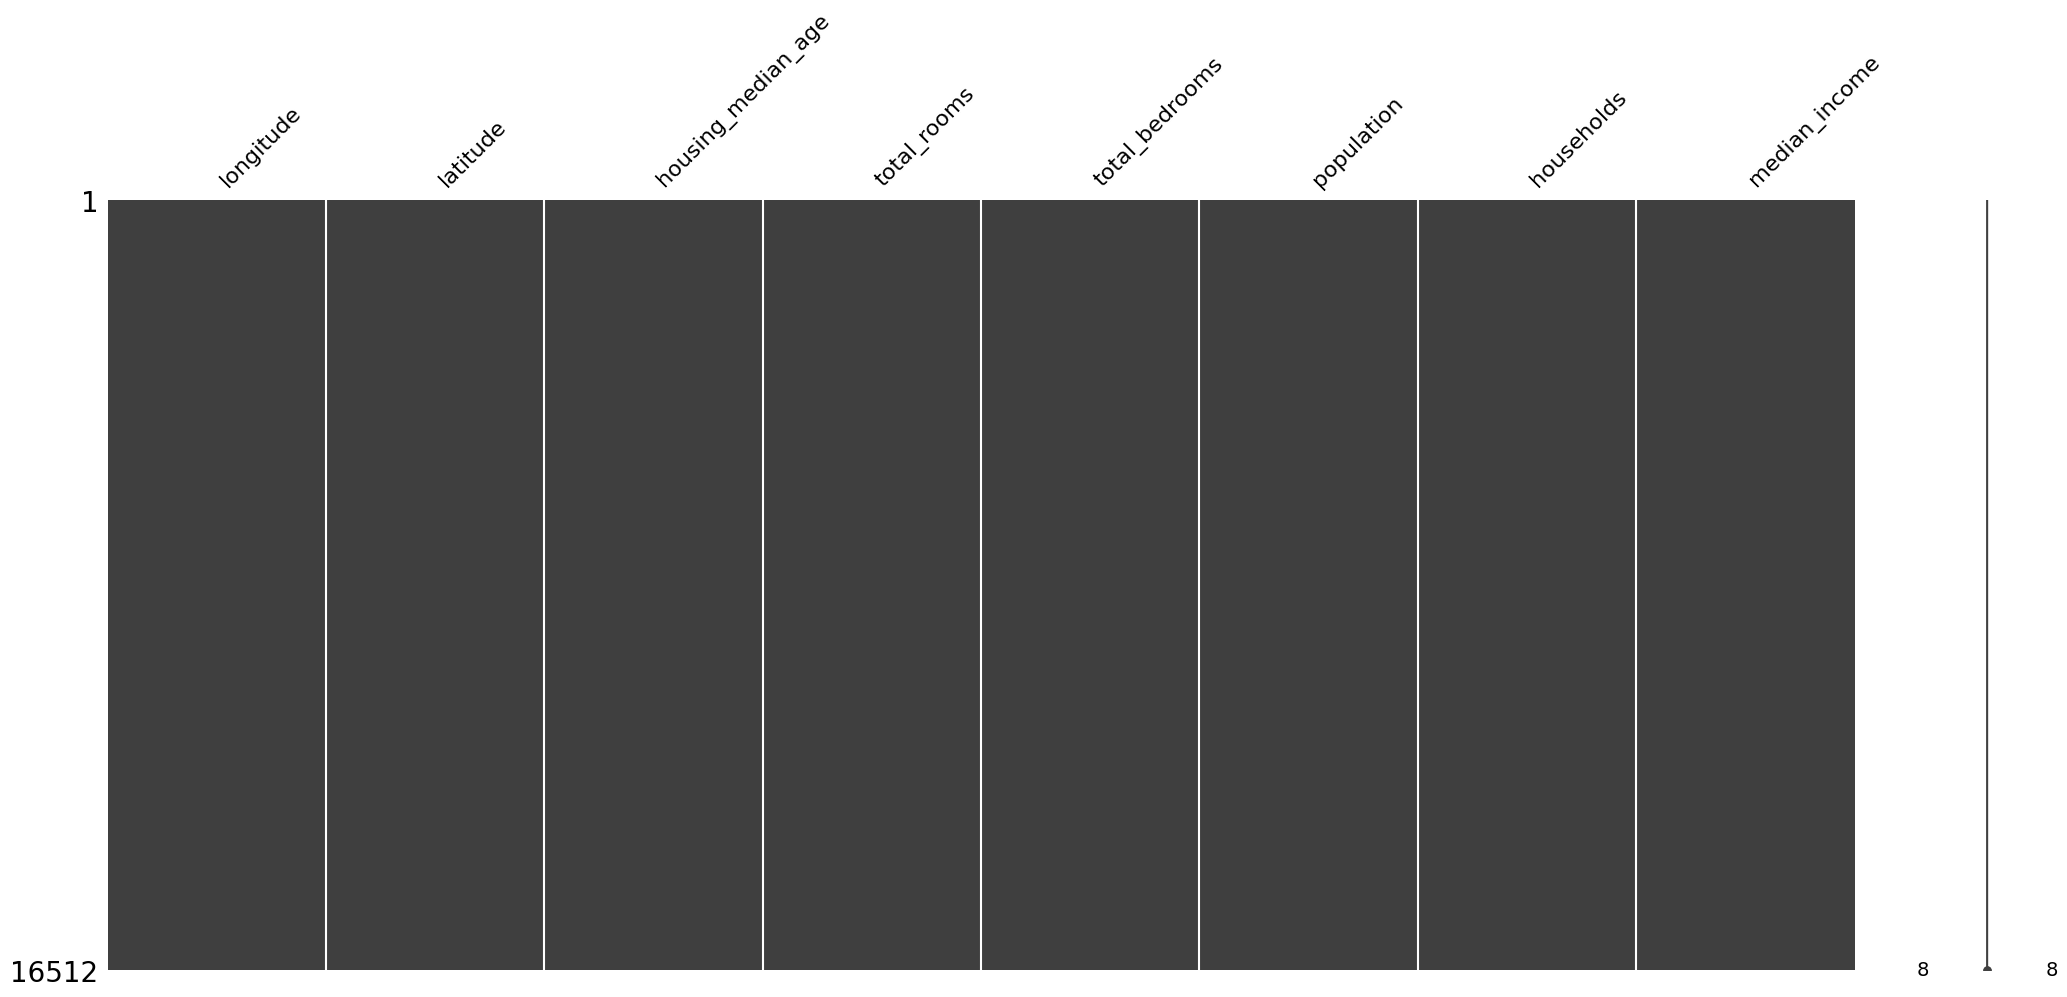

In [67]:
msno.matrix(housing_tr)

In [68]:
housing_tr.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964


# Feature Engineering

## Feature scaling

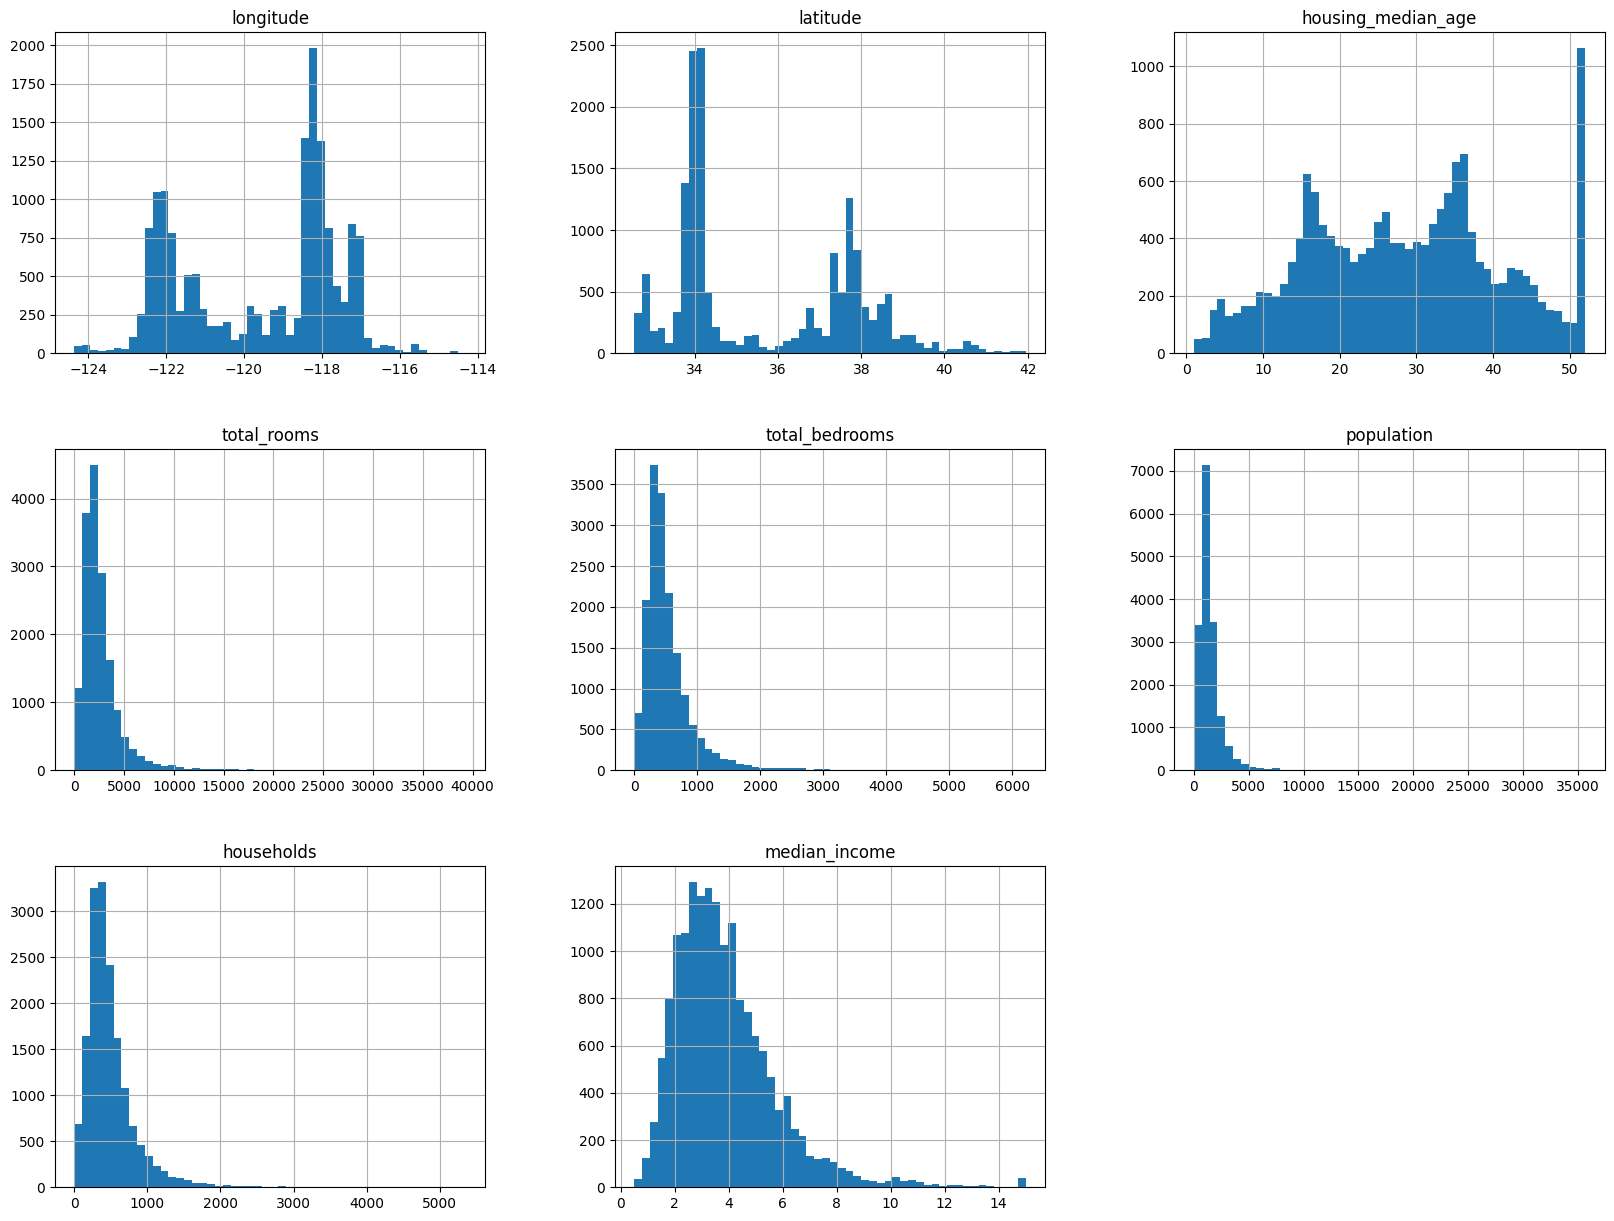

In [69]:
housing_tr.hist(bins=50, figsize=(20, 15))
plt.show()

In [70]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [71]:
std_scaler = StandardScaler()
minmax_scaler = MinMaxScaler()

housing_num_std = std_scaler.fit_transform(housing_num)
housing_num_minmax = minmax_scaler.fit_transform(housing_num)

housing_num_std_df = pd.DataFrame(housing_num_std, columns=housing_num.columns, index=housing_num.index)
housing_num_minmax_df = pd.DataFrame(housing_num_minmax, columns=housing_num.columns, index=housing_num.index)

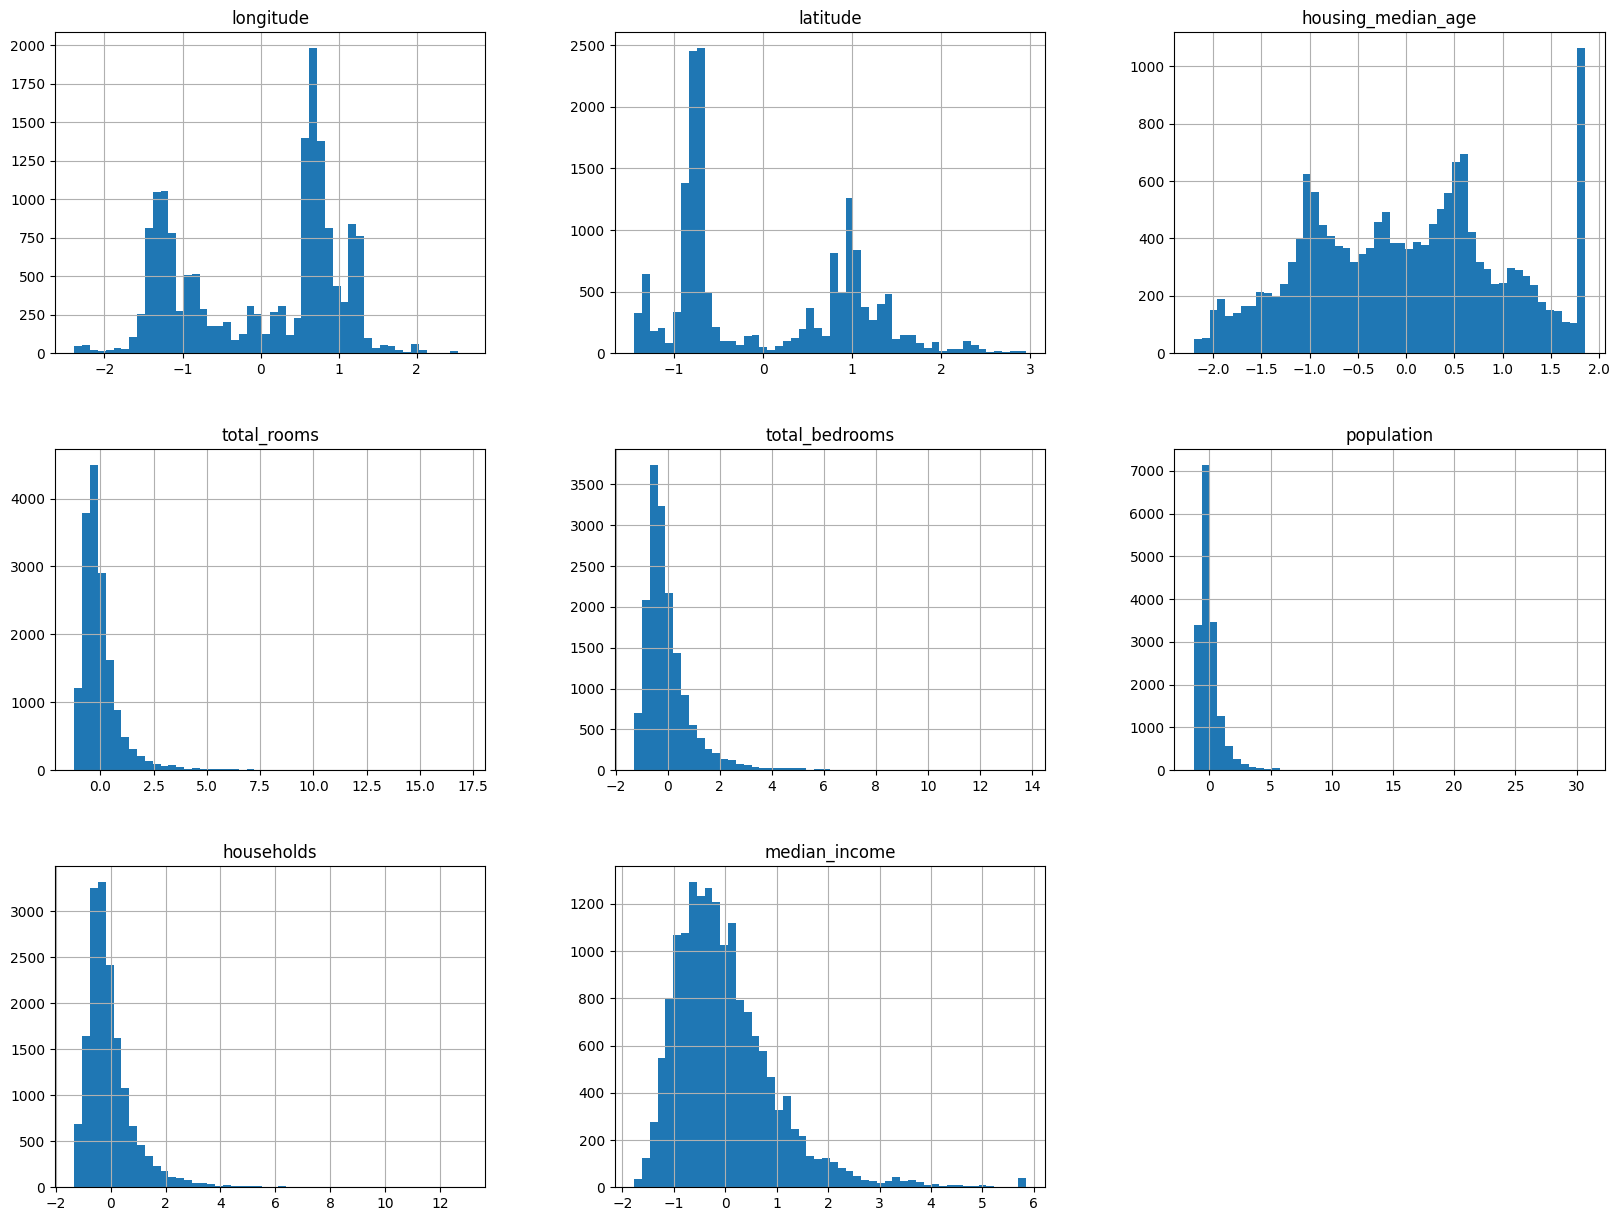

In [72]:
housing_num_std_df.hist(bins=50, figsize=(20, 15))
plt.show()

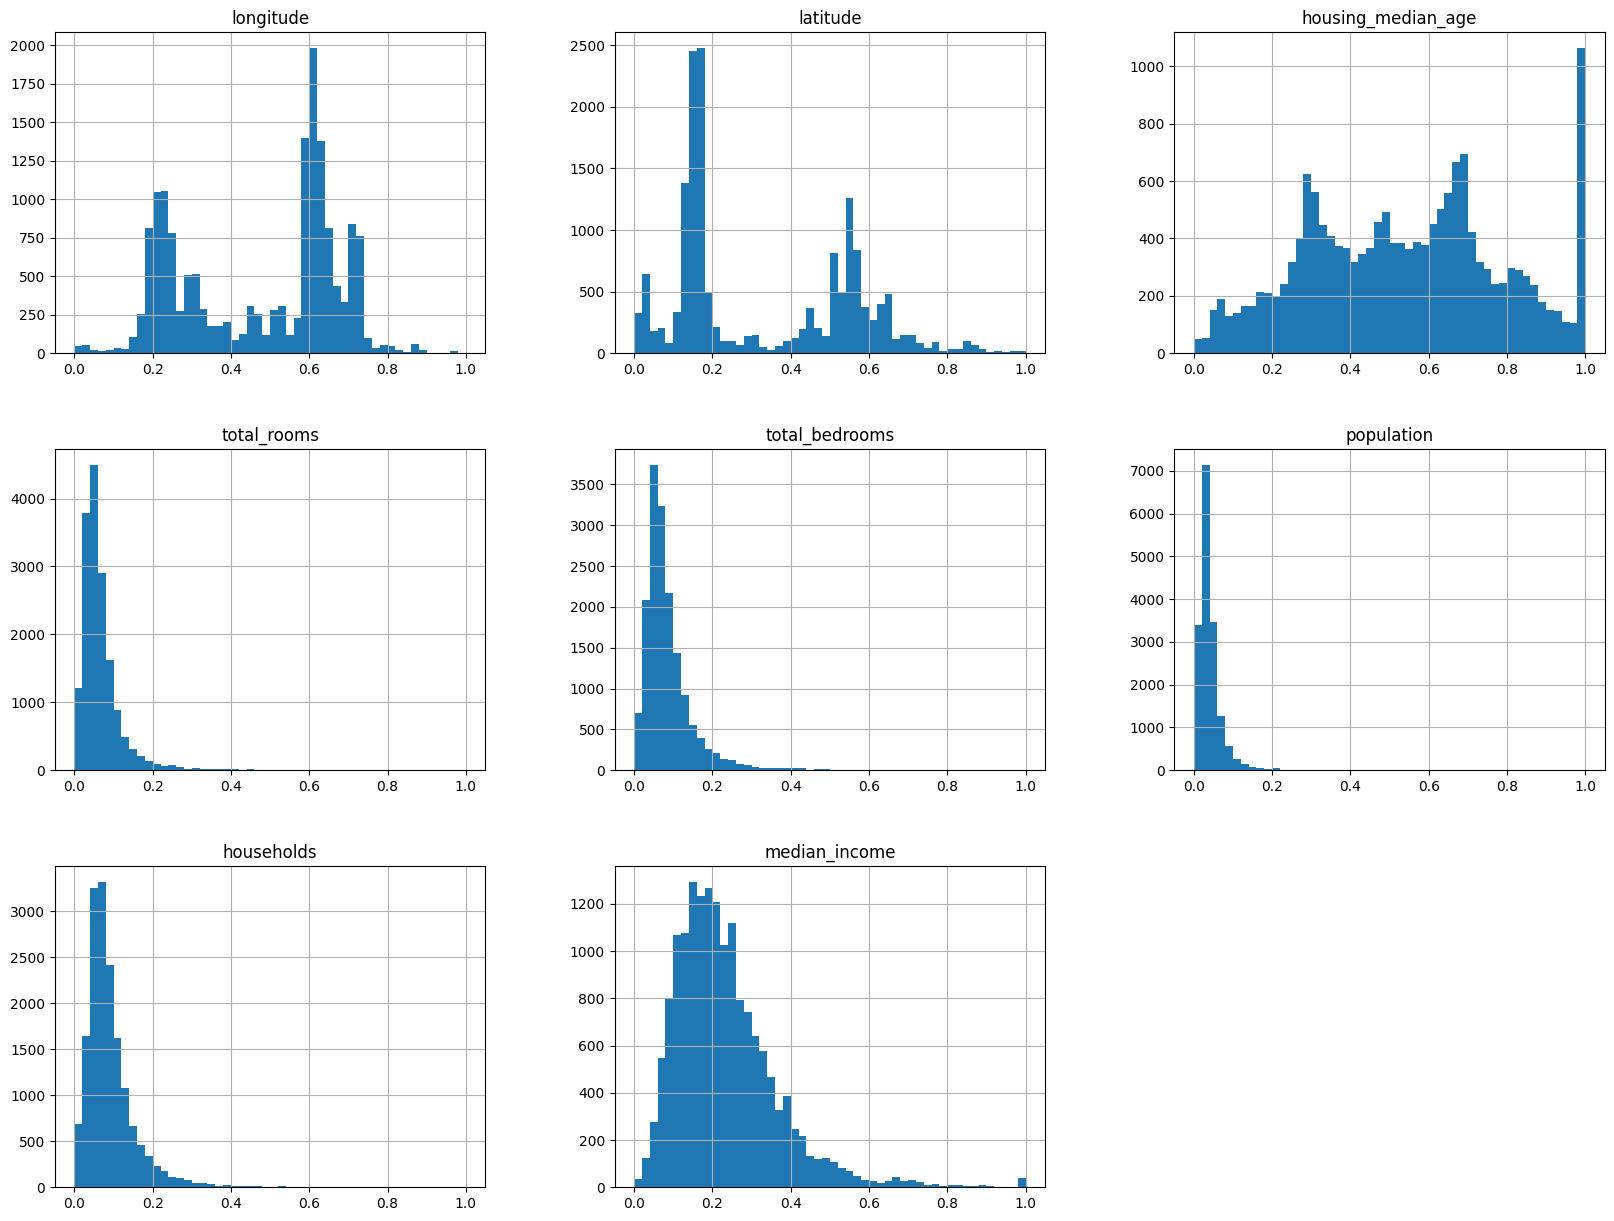

In [73]:
housing_num_minmax_df.hist(bins=50, figsize=(20, 15))
plt.show()

# Handle Categorical Variables

In [74]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16354 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   ocean_proximity     16512 non-null  object  
 9   income_cat          16512 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.8+ MB


In [75]:
housing[['ocean_proximity']].value_counts()

ocean_proximity
<1H OCEAN          7277
INLAND             5262
NEAR OCEAN         2124
NEAR BAY           1847
ISLAND                2
Name: count, dtype: int64

In [76]:
housing_cat = housing[['ocean_proximity']]

In [77]:
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

In [98]:
ordinal_encoder = OrdinalEncoder()
ordinal_encoder.fit(housing_cat)

ordinal_encoder.categories_

housing_cat_encoded = ordinal_encoder.transform(housing_cat)

housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [78]:
ordinal_encoder = OrdinalEncoder()
housing_cat_encoded = ordinal_encoder.fit_transform(housing_cat)
housing_cat_encoded[:10]

array([[1.],
       [4.],
       [1.],
       [4.],
       [0.],
       [3.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [79]:
ordinal_encoder.categories_

[array(['<1H OCEAN', 'INLAND', 'ISLAND', 'NEAR BAY', 'NEAR OCEAN'],
       dtype=object)]

In [80]:
ohe = OneHotEncoder()
housing_cat_1hot = ohe.fit_transform(housing_cat)
housing_cat_1hot[:10]

<10x5 sparse matrix of type '<class 'numpy.float64'>'
	with 10 stored elements in Compressed Sparse Row format>

In [81]:
# Get feature names from 'ohe'
feature_names = ohe.categories_[0]

# Convert sparse matrix to a dense numpy array
housing_cat_1hot_array = housing_cat_1hot.toarray()

# Convert numpy array to DataFrame
housing_cat_1hot_df = pd.DataFrame(housing_cat_1hot_array, columns=feature_names)

# Display the first 10 rows of the DataFrame
housing_cat_1hot_df.head(10)

,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN
0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0
4,1.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,1.0,0.0
6,1.0,0.0,0.0,0.0,0.0
7,1.0,0.0,0.0,0.0,0.0
8,1.0,0.0,0.0,0.0,0.0
9,1.0,0.0,0.0,0.0,0.0


# What we have done so far

- Handled Missing Values
- Scaling -> numerical variables
- Handled Categorical Variables -> OneHotEncoding   

X = housing_num_std_df, housing_cat_1hot_df
y = housing_labels


# Building the model

In [82]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,2
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,5
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,2
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,2
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,3


In [83]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 16512 entries, 12655 to 19773
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   longitude           16512 non-null  float64 
 1   latitude            16512 non-null  float64 
 2   housing_median_age  16512 non-null  float64 
 3   total_rooms         16512 non-null  float64 
 4   total_bedrooms      16354 non-null  float64 
 5   population          16512 non-null  float64 
 6   households          16512 non-null  float64 
 7   median_income       16512 non-null  float64 
 8   ocean_proximity     16512 non-null  object  
 9   income_cat          16512 non-null  category
dtypes: category(1), float64(8), object(1)
memory usage: 1.8+ MB


In [85]:
num_attributes = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 
                  'population', 'households', 'median_income']
cat_attributes = ['ocean_proximity']

In [87]:
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('std_scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ohe', OneHotEncoder(handle_unknown='ignore'))
])

Pipeline(steps=[('imputer', SimpleImputer(strategy='most_frequent')),
                ('ohe', OneHotEncoder(handle_unknown='ignore'))])

In [88]:
from sklearn import preprocessing
from sklearn.compose import ColumnTransformer

preprocessing_pipeline = ColumnTransformer([
    ('num', num_pipeline, num_attributes),
    ('cat', cat_pipeline, cat_attributes),
])

preprocessing_pipeline

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('std_scaler',
                                                  StandardScaler())]),
                                 ['longitude', 'latitude', 'housing_median_age',
                                  'total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ohe',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['ocean_proximity'])])

In [89]:
from sklearn.linear_model import LinearRegression

lin_reg_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('lin_reg', LinearRegression())
])

lin_reg_pipeline

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('std_scaler',
                                                                   StandardScaler())]),
                                                  ['longitude', 'latitude',
                                                   'housing_median_age',
                                                   'total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ohe',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['ocean_proximity'])])),
                ('lin_reg', LinearRegression())])

In [90]:
lin_model = lin_reg_pipeline.fit(housing, housing_labels)

In [94]:
print(lin_model.named_steps['lin_reg'].coef_)
print(lin_model.named_steps['lin_reg'].intercept_)

[-53158.46752879 -54016.74420924  13723.55752923 -10022.16419715
  29937.91903315 -43815.82009104  28900.33562175  73737.44249419
 -18139.05294479 -57836.49981854 112925.81797133 -22517.51078879
 -14432.75441921]
237792.1871670136


In [95]:
housing.iloc[:5]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,income_cat
12655,-121.46,38.52,29.0,3873.0,797.0,2237.0,706.0,2.1736,INLAND,2
15502,-117.23,33.09,7.0,5320.0,855.0,2015.0,768.0,6.3373,NEAR OCEAN,5
2908,-119.04,35.37,44.0,1618.0,310.0,667.0,300.0,2.8750,INLAND,2
14053,-117.13,32.75,24.0,1877.0,519.0,898.0,483.0,2.2264,NEAR OCEAN,2
20496,-118.70,34.28,27.0,3536.0,646.0,1837.0,580.0,4.4964,<1H OCEAN,3


In [96]:
housing_prediction = lin_model.predict(housing.iloc[:5])
housing_prediction

array([ 88983.14806384, 305351.35385026, 153334.71183453, 184302.55162102,
       246840.18988841])

In [100]:
from sklearn.tree import DecisionTreeRegressor

dt_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('dt_reg', DecisionTreeRegressor())
])

dt_model = dt_pipeline.fit(housing, housing_labels)

In [101]:
dt_model.named_steps['dt_reg'].feature_importances_

array([0.11395725, 0.11520077, 0.04928105, 0.0227789 , 0.01731629,
       0.02892855, 0.02108129, 0.47797247, 0.004345  , 0.1430734 ,
       0.        , 0.00127243, 0.00479262])

In [105]:
from sklearn.metrics import root_mean_squared_error

housing_predictions = lin_model.predict(strat_test_set.drop('median_house_value', axis=1)

lin_rmse = root_mean_squared_error(strat_test_set['median_house_value'], housing_predictions)

In [106]:
lin_rmse

69050.56219504567

In [107]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ('preprocessing', preprocessing_pipeline),
    ('rf_reg', RandomForestRegressor())
])

rf_model = rf_pipeline.fit(housing, housing_labels)

housing_predictions = rf_model.predict(housing)

rf_rmse = root_mean_squared_error(housing_labels, housing_predictions)

rf_rmse


18331.003749154344

# save the best model

In [108]:
import joblib

joblib.dump(rf_model, '../models/random_forest_model.pkl')

['../models/random_forest_model.pkl']